In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
# pickle is used to save Python objects to a file
# We will use it to save our scaler so we can reuse it in Phase 4 and 5
#pickle lets us save Python objects — we need this to save the scaler because
#we will need the exact same scaler later in Phase 5 to convert predictions back to real dollar prices.
import pickle

In [2]:
df = pd.read_csv('final_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
print('Shape:', df.shape)
print('First 3 rows: ')
print(df.head(3))
print('All columns:')
for i, col in enumerate(df.columns):
    print(i + 1, '-', col)

Shape: (2583, 16)
First 3 rows: 
        date      Close       High        Low       Open     Volume  \
0 2016-01-05  23.114971  23.821631  23.047457  23.799126  223164000   
1 2016-01-06  22.662607  23.038443  22.475816  22.631100  273829600   
2 2016-01-07  21.706148  22.534335  21.701648  22.208012  324377600   

   news_count  avg_sentiment  max_sentiment  min_sentiment  high_impact_count  \
0         2.0          0.000         0.0000          0.000                0.0   
1         1.0          0.000         0.0000          0.000                0.0   
2        11.0          0.054         0.3612         -0.128                0.0   

   medium_impact_count  negative_count  daily_return  price_range     Target  
0                  0.0             0.0     -2.505921     0.774174  22.662607  
1                  0.0             0.0     -1.957017     0.562627  21.706148  
2                  3.0             1.0     -4.220428     0.832687  21.820923  
All columns:
1 - date
2 - Close
3 - High


In [3]:
feature_columns = [
    'Close', 'Open', 'High', 'Low', 'Volume',
    'daily_return', 'price_range',
    'news_count', 'avg_sentiment', 'max_sentiment', 'min_sentiment',
    'high_impact_count', 'medium_impact_count', 'negative_count'
]

feature_columns = [col for col in feature_columns if col in df.columns]

print('Feature columns we will use:')
for i, col in enumerate(feature_columns):
    print(i + 1, '-', col)

print('Total number of features:', len(feature_columns))

Feature columns we will use:
1 - Close
2 - Open
3 - High
4 - Low
5 - Volume
6 - daily_return
7 - price_range
8 - news_count
9 - avg_sentiment
10 - max_sentiment
11 - min_sentiment
12 - high_impact_count
13 - medium_impact_count
14 - negative_count
Total number of features: 14


In [4]:
# We split by TIME - not randomly
# Why? Because we want to test on FUTURE data, not random past days
# If we split randomly, the model might "see" future data during training
# which would be cheating

# Calculate the split index
total_rows = len(df)
train_size = int(total_rows * 0.80)

train_df = df.iloc[:train_size]
test_df  = df.iloc[train_size:]

print('Total rows :', total_rows)
print('Training rows  :', len(train_df), '(80%)')
print('Testing rows :', len(test_df),  '(20%)')
print('Training data from:', train_df['date'].min().date(), 'to', train_df['date'].max().date())
print('Testing data from :', test_df['date'].min().date(),  'to', test_df['date'].max().date())

Total rows : 2583
Training rows  : 2066 (80%)
Testing rows : 517 (20%)
Training data from: 2016-01-05 to 2024-03-20
Testing data from : 2024-03-21 to 2026-04-14


In [5]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

train_features = train_df[feature_columns].values
test_features  = test_df[feature_columns].values

train_features_scaled = feature_scaler.fit_transform(train_features)
test_features_scaled  = feature_scaler.transform(test_features)

train_target = train_df['Target'].values.reshape(-1, 1)
target_scaler.fit(train_target)

train_target = train_df['Target'].values.reshape(-1, 1)
test_target  = test_df['Target'].values.reshape(-1, 1)

train_target_scaled = target_scaler.transform(train_target)
test_target_scaled  = target_scaler.transform(test_target)

print('Target scaler range:')
print('Min price:', round(target_scaler.data_min_[0], 2))
print('Max price:', round(target_scaler.data_max_[0], 2))

print('All feature values between 0 and 1:')
print('Min:', train_features_scaled.min().round(4))
print('Max:', train_features_scaled.max().round(4))

Target scaler range:
Min price: 20.57
Max price: 285.66
All feature values between 0 and 1:
Min: 0.0
Max: 1.0


In [6]:
# LSTM does not take one row at a time as input
# It takes a SEQUENCE of rows - a window of past days
# We use a window of 60 days
# This means: "look at the last 60 days of data, predict the next day"

# This function creates sequences from our scaled data
def create_sequences(features, target, window_size):

    X = []   # will hold the input sequences (60 days of features)
    y = []   # will hold the target values (next day price)

    # Start from row 'window_size' so we always have 60 previous rows
    for i in range(window_size, len(features)):

        # Take the last 60 rows of features as one input sequence
        X.append(features[i - window_size : i])

        # Take the target value for the current row (next day price)
        y.append(target[i])

    # Convert lists to numpy arrays
    X = np.array(X)
    y = np.array(y)

    return X, y

# Set window size to 60 days
WINDOW_SIZE = 60

# Create sequences for training data
X_train, y_train = create_sequences(train_features_scaled, train_target_scaled, WINDOW_SIZE)

# Create sequences for testing data
X_test, y_test = create_sequences(test_features_scaled, test_target_scaled, WINDOW_SIZE)

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape :', X_test.shape)
print('y_test shape :', y_test.shape)
print('Reading X_train shape as (samples, window_size, features):')
print('Number of training samples :', X_train.shape[0])
print('Days in each sequence :', X_train.shape[1], '(60 days)')
print('Features per day  :', X_train.shape[2])

X_train shape: (2006, 60, 14)
y_train shape: (2006, 1)
X_test shape : (457, 60, 14)
y_test shape : (457, 1)
Reading X_train shape as (samples, window_size, features):
Number of training samples : 2006
Days in each sequence : 60 (60 days)
Features per day  : 14


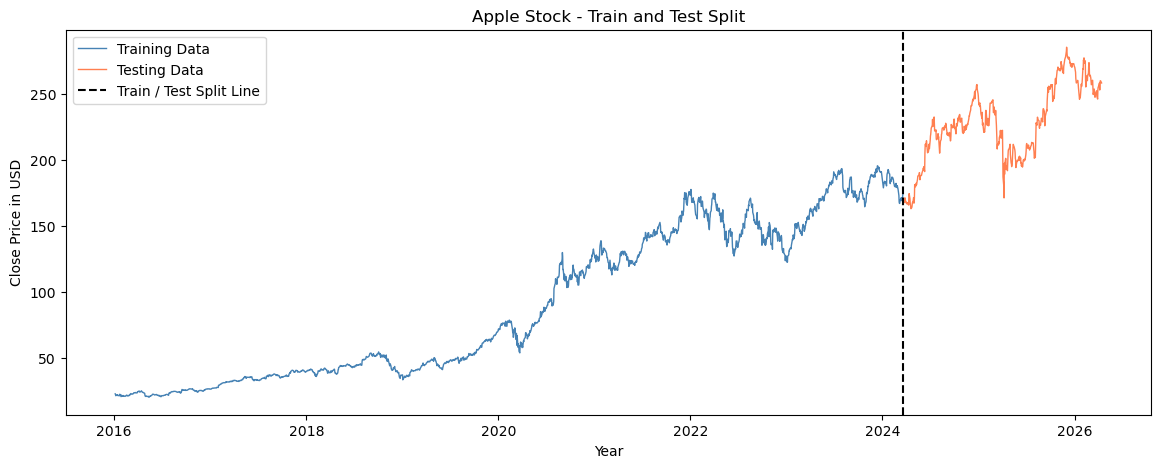

In [7]:
# Draw a chart showing which part of the data is train and which is test
plt.figure(figsize=(14, 5))
plt.plot(train_df['date'], train_df['Close'],
         color='steelblue', linewidth=1, label='Training Data')

plt.plot(test_df['date'], test_df['Close'],
         color='coral', linewidth=1, label='Testing Data')

split_date = test_df['date'].iloc[0]
plt.axvline(split_date, color='black', linestyle='--', linewidth=1.5,
            label='Train / Test Split Line')

plt.title('Apple Stock - Train and Test Split')
plt.xlabel('Year')
plt.ylabel('Close Price in USD')
plt.legend()
plt.show()

In [8]:

# Save the numpy arrays
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_test.npy',  X_test)
np.save('y_test.npy',  y_test)

# Save the scalers using pickle
# We MUST save the target_scaler because we need it in Phase 5
# to convert predicted values back to real dollar prices
with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(feature_scaler, f)

with open('target_scaler.pkl', 'wb') as f:
    pickle.dump(target_scaler, f)

# Save the list of feature columns as well
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)
